# Notebook 01 — European Options: Black-Scholes Model

**Option Pricing Horizon** | Task 1 of 5

---

## Learning Objectives
1. Derive the Black-Scholes PDE from risk-neutral GBM dynamics
2. Understand the closed-form call/put formulas and the role of d₁, d₂
3. Price vanilla European options interactively
4. Visualise option prices across spot prices, strikes, and volatilities
5. Understand and plot all five Greeks

---

## 1. Theoretical Foundation

### 1.1 Risk-Neutral GBM Dynamics

Under the **risk-neutral measure Q**, the underlying asset price $S_t$ follows:

$$dS_t = r S_t \, dt + \sigma S_t \, dW_t^Q$$

where:
- $r$ = continuously compounded risk-free rate
- $\sigma$ = annualised volatility
- $W_t^Q$ = standard Brownian motion under Q

The exact solution is:
$$S_T = S_0 \exp\!\left[\left(r - \tfrac{\sigma^2}{2}\right)T + \sigma W_T^Q\right]$$

So $\ln(S_T/S_0) \sim \mathcal{N}\!\left((r - \sigma^2/2)T,\; \sigma^2 T\right)$.

### 1.2 Black-Scholes Pricing Formula

The no-arbitrage price of a European call is the discounted risk-neutral expectation:

$$C = e^{-rT} \mathbb{E}^Q\!\left[\max(S_T - K,\, 0)\right]$$

Evaluating analytically using the log-normal distribution:

$$\boxed{C = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2)}$$

$$\boxed{P = K e^{-rT} \Phi(-d_2) - S_0 \Phi(-d_1)}$$

where:
$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $\Phi(\cdot)$ is the standard normal CDF.

### 1.3 Intuition for d₁ and d₂

| Quantity | Interpretation |
|----------|---------------|
| $\Phi(d_2)$ | Risk-neutral probability that $S_T > K$ (option expires in-the-money) |
| $\Phi(d_1)$ | Delta of the call = expected share of $S_T$ received above $K$ |
| $K e^{-rT} \Phi(d_2)$ | Present value of the expected strike payment |
| $S_0 \Phi(d_1)$ | Present value of the expected stock receipt |

### 1.4 Put-Call Parity

$$C - P = S_0 - K e^{-rT}$$

This is **model-free** and follows from no-arbitrage alone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from option_pricing_horizon.common.market_params import MarketParams
from option_pricing_horizon.common.math_utils import norm_cdf, bs_d1, bs_d2
from option_pricing_horizon.european.black_scholes import (
    bs_call_price, bs_put_price, bs_price, implied_volatility
)
from option_pricing_horizon.european.greeks import (
    bs_delta, bs_gamma, bs_theta, bs_vega, bs_rho, bs_all_greeks
)

# Matplotlib style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# Baseline market parameters (from project brief / image.png)
mp = MarketParams.baseline()   # S0=100, K=100, r=3%, sigma=20%, T=1yr
print(mp)

MarketParams(S0=100.0, K=100.0, r=0.03, sigma=0.2, T=1.0, N=252, q=0.0)


## 2. Computing d₁, d₂ and the ATM Option Price

In [2]:
d1 = bs_d1(mp.S0, mp.K, mp.r, mp.sigma, mp.T)
d2 = bs_d2(mp.S0, mp.K, mp.r, mp.sigma, mp.T)
call = bs_call_price(mp.S0, mp.K, mp.r, mp.sigma, mp.T)
put  = bs_put_price(mp.S0, mp.K, mp.r, mp.sigma, mp.T)

# Verify put-call parity
parity_lhs = call - put
parity_rhs = mp.S0 - mp.K * np.exp(-mp.r * mp.T)
parity_error = abs(parity_lhs - parity_rhs)

print(f"{'='*52}")
print(f"  Baseline Black-Scholes Pricing Results")
print(f"{'='*52}")
print(f"  Parameters : S0={mp.S0}, K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr")
print(f"  d1         : {d1:+.6f}")
print(f"  d2         : {d2:+.6f}")
print(f"  Φ(d1)      : {norm_cdf(d1):.6f}  ← call delta")
print(f"  Φ(d2)      : {norm_cdf(d2):.6f}  ← P(S_T > K) under Q")
print(f"  Call Price : ${call:.6f}")
print(f"  Put  Price : ${put:.6f}")
print(f"  Put-Call Parity Error: {parity_error:.2e}  (should be ~0)")
print(f"{'='*52}")

  Baseline Black-Scholes Pricing Results
  Parameters : S0=100.0, K=100.0, r=3%, σ=20%, T=1.0yr
  d1         : +0.250000
  d2         : +0.050000
  Φ(d1)      : 0.598706  ← call delta
  Φ(d2)      : 0.519939  ← P(S_T > K) under Q
  Call Price : $9.413403
  Put  Price : $6.457957
  Put-Call Parity Error: 0.00e+00  (should be ~0)


## 3. Option Price vs Spot Price

We sweep the spot price $S_0 \in [60, 150]$ and observe how call and put prices change,
along with the intrinsic values and the time-value component.

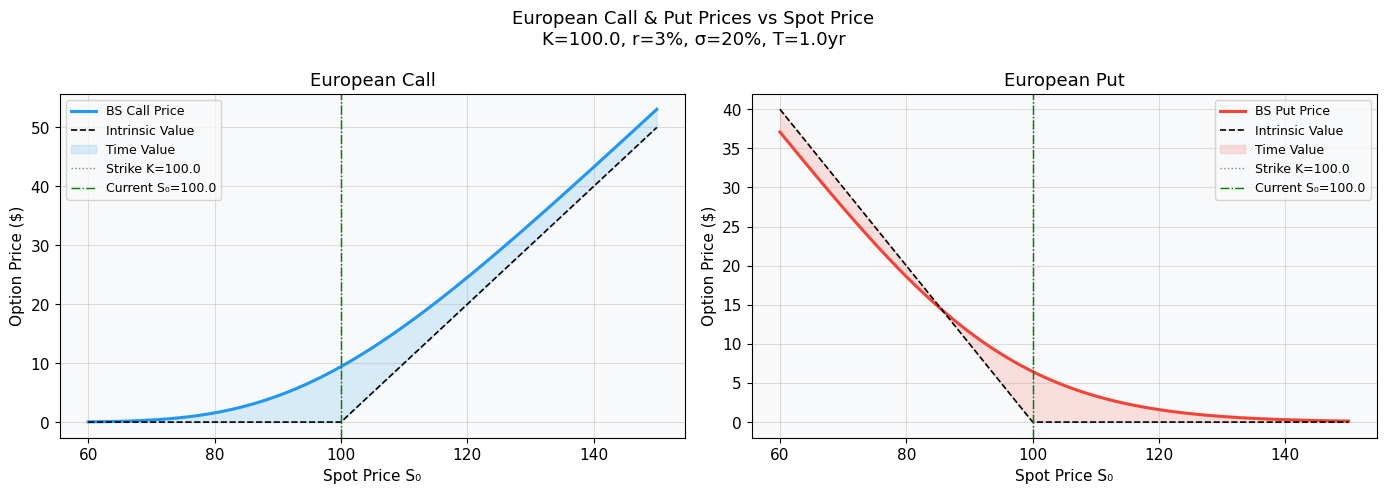

In [3]:
S_range = np.linspace(60, 150, 300)
K, r, sigma, T = mp.K, mp.r, mp.sigma, mp.T

calls   = np.array([bs_call_price(S, K, r, sigma, T) for S in S_range])
puts    = np.array([bs_put_price(S, K, r, sigma, T)  for S in S_range])
intrinsic_call = np.maximum(S_range - K, 0)
intrinsic_put  = np.maximum(K - S_range, 0)
tv_call = calls - intrinsic_call
tv_put  = puts  - intrinsic_put

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('European Call & Put Prices vs Spot Price\n'
             f'K={K}, r={r:.0%}, σ={sigma:.0%}, T={T}yr', fontsize=13)

for ax, prices, intrinsic, tv, label, color in [
    (axes[0], calls, intrinsic_call, tv_call, 'Call', '#2196F3'),
    (axes[1], puts,  intrinsic_put,  tv_put,  'Put',  '#F44336'),
]:
    ax.plot(S_range, prices,    color=color,   lw=2.2, label=f'BS {label} Price')
    ax.plot(S_range, intrinsic, color='black', lw=1.2, ls='--', label='Intrinsic Value')
    ax.fill_between(S_range, intrinsic, prices, alpha=0.15, color=color, label='Time Value')
    ax.axvline(K, color='grey', lw=1, ls=':', label=f'Strike K={K}')
    ax.axvline(mp.S0, color='green', lw=1, ls='-.', label=f'Current S₀={mp.S0}')
    ax.set_xlabel('Spot Price S₀')
    ax.set_ylabel('Option Price ($)')
    ax.set_title(f'European {label}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Option Price Surface: Spot × Volatility

A 3-D surface showing how the call price varies with both spot price and volatility.

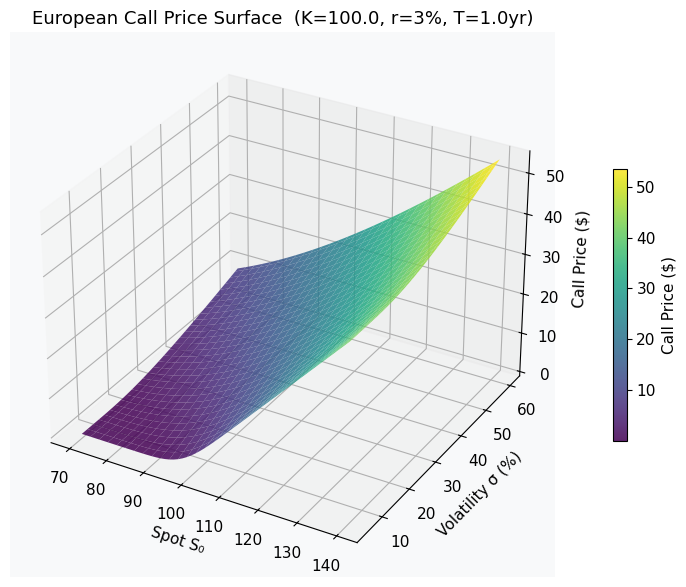

In [4]:
S_grid  = np.linspace(70, 140, 60)
sig_grid = np.linspace(0.05, 0.60, 60)
SS, SIG = np.meshgrid(S_grid, sig_grid)

call_surface = np.vectorize(lambda s, v: bs_call_price(s, K, r, v, T))(SS, SIG)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(SS, SIG * 100, call_surface, cmap='viridis', alpha=0.85)
ax.set_xlabel('Spot S₀')
ax.set_ylabel('Volatility σ (%)')
ax.set_zlabel('Call Price ($)')
ax.set_title(f'European Call Price Surface  (K={K}, r={r:.0%}, T={T}yr)')
fig.colorbar(surf, ax=ax, shrink=0.5, label='Call Price ($)')
plt.tight_layout()
plt.show()

## 5. The Greeks

The **Greeks** measure sensitivities of the option price to market parameters.
They are the primary tools for **hedging** and **risk management**.

| Greek | Formula | Interpretation |
|-------|---------|---------------|
| **Delta** Δ | $\partial C / \partial S$ | Change in price per $1 move in S |
| **Gamma** Γ | $\partial^2 C / \partial S^2$ | Rate of change of Delta |
| **Theta** Θ | $\partial C / \partial t$ | Time decay (per calendar day) |
| **Vega** V | $\partial C / \partial \sigma$ | Sensitivity to volatility (per 1%) |
| **Rho** ρ | $\partial C / \partial r$ | Sensitivity to interest rate (per 1%) |

In [5]:
# Compute all Greeks at baseline
g = bs_all_greeks(mp.S0, mp.K, mp.r, mp.sigma, mp.T, 'call')
g_put = bs_all_greeks(mp.S0, mp.K, mp.r, mp.sigma, mp.T, 'put')

greeks_df = pd.DataFrame({
    'Call': g,
    'Put':  g_put
}).rename(index=str.title)
greeks_df.index.name = 'Greek'

print("\n  Black-Scholes Greeks at Baseline Parameters")
print(f"  S0={mp.S0}, K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr")
print()
print(greeks_df.to_string(float_format='{:.6f}'.format))
print("\n  Note: Theta is per calendar day; Vega & Rho are per 1% change.")


  Black-Scholes Greeks at Baseline Parameters
  S0=100.0, K=100.0, r=3%, σ=20%, T=1.0yr

           Call       Put
Greek                    
Delta  0.598706 -0.401294
Gamma  0.019333  0.019333
Theta -0.014741 -0.006765
Vega   0.386668  0.386668
Rho    0.504572 -0.465873

  Note: Theta is per calendar day; Vega & Rho are per 1% change.


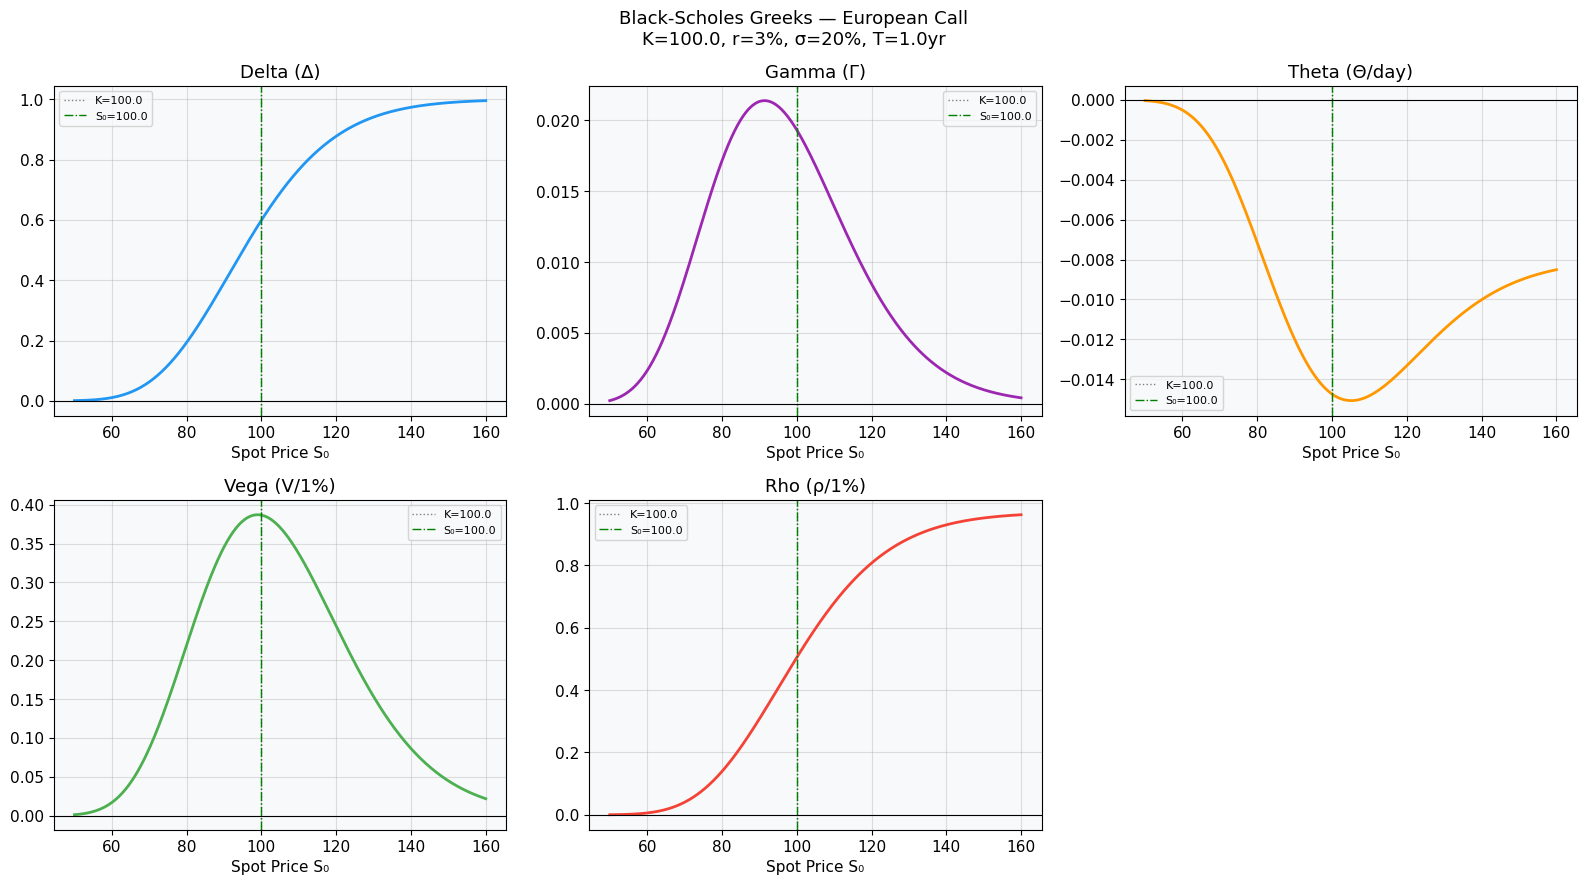

In [6]:
# Plot all 5 Greeks vs spot price
S_range = np.linspace(50, 160, 400)

greeks_call = {
    'Delta (Δ)':  [bs_delta(S, K, r, sigma, T, 'call') for S in S_range],
    'Gamma (Γ)':  [bs_gamma(S, K, r, sigma, T)          for S in S_range],
    'Theta (Θ/day)': [bs_theta(S, K, r, sigma, T, 'call', per_day=True) for S in S_range],
    'Vega (V/1%)':   [bs_vega(S, K, r, sigma, T, per_percent=True)  for S in S_range],
    'Rho (ρ/1%)':    [bs_rho(S, K, r, sigma, T, 'call', per_percent=True)  for S in S_range],
}

colors = ['#2196F3', '#9C27B0', '#FF9800', '#4CAF50', '#F44336']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()
fig.suptitle('Black-Scholes Greeks — European Call\n'
             f'K={K}, r={r:.0%}, σ={sigma:.0%}, T={T}yr', fontsize=13)

for idx, (name, values) in enumerate(greeks_call.items()):
    ax = axes_flat[idx]
    ax.plot(S_range, values, color=colors[idx], lw=2)
    ax.axvline(K,     color='grey',  lw=1, ls=':',  label=f'K={K}')
    ax.axvline(mp.S0, color='green', lw=1, ls='-.', label=f'S₀={mp.S0}')
    ax.axhline(0,     color='black', lw=0.8, ls='-')
    ax.set_xlabel('Spot Price S₀')
    ax.set_title(name)
    ax.legend(fontsize=8)

axes_flat[5].set_visible(False)  # hide 6th panel
plt.tight_layout()
plt.show()

## 6. Delta-Neutral Hedging Intuition

A **delta-neutral** portfolio holds:
- Long 1 call (Delta = Δ_call ≈ 0.53)
- Short Δ_call shares of stock

This portfolio has **zero instantaneous sensitivity** to small moves in $S$.
However, Gamma exposure means we need to rebalance as $S$ moves.

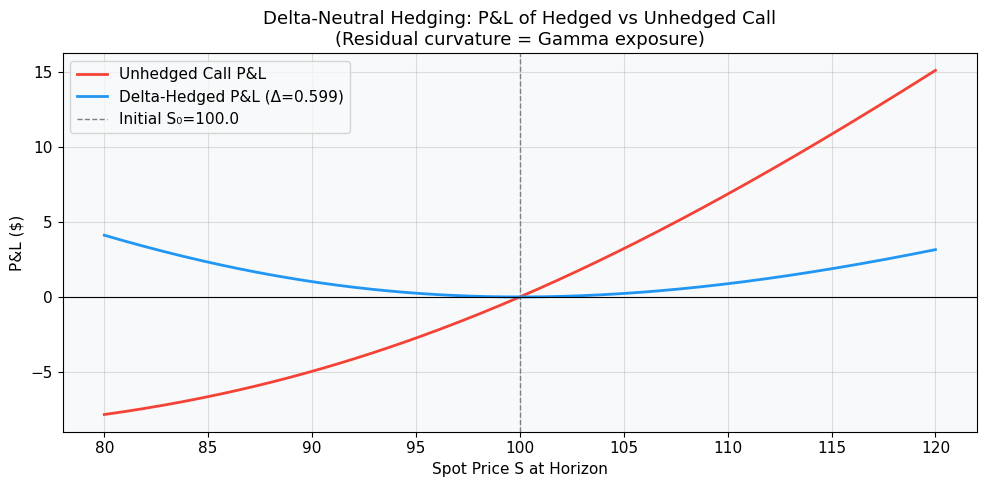


Call Delta at S₀=100.0: 0.5987
Interpretation: for every $1 rise in S, the call rises ~$0.5987
We short 0.5987 shares to neutralise this exposure.
Residual P&L from Gamma: the hedged P&L is a parabola — we profit from large moves (long gamma).


In [7]:
# Demonstrate delta hedging: P&L of hedged vs unhedged position for a spot move
S_range_hedge = np.linspace(80, 120, 300)
S0_hedge = 100.0
delta0   = bs_delta(S0_hedge, K, r, sigma, T, 'call')
call0    = bs_call_price(S0_hedge, K, r, sigma, T)

# Unhedged: just long the call
pnl_unhedged = np.array([bs_call_price(S, K, r, sigma, T) - call0 for S in S_range_hedge])

# Delta-hedged: long call, short delta0 shares
pnl_hedged = pnl_unhedged - delta0 * (S_range_hedge - S0_hedge)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S_range_hedge, pnl_unhedged, label='Unhedged Call P&L', lw=2, color='#F44336')
ax.plot(S_range_hedge, pnl_hedged,   label=f'Delta-Hedged P&L (Δ={delta0:.3f})', lw=2, color='#2196F3')
ax.axvline(S0_hedge, color='grey', lw=1, ls='--', label=f'Initial S₀={S0_hedge}')
ax.axhline(0,        color='black', lw=0.8)
ax.set_xlabel('Spot Price S at Horizon')
ax.set_ylabel('P&L ($)')
ax.set_title('Delta-Neutral Hedging: P&L of Hedged vs Unhedged Call\n'
             '(Residual curvature = Gamma exposure)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nCall Delta at S₀={S0_hedge}: {delta0:.4f}")
print(f"Interpretation: for every $1 rise in S, the call rises ~${delta0:.4f}")
print(f"We short {delta0:.4f} shares to neutralise this exposure.")
print(f"Residual P&L from Gamma: the hedged P&L is a parabola — we profit from large moves (long gamma).")

## 7. Implied Volatility — Round-Trip Check and Smile

The **implied volatility (IV)** is the $\sigma$ value that makes the BS model price equal
to the observed market price. Here we verify the round-trip and plot a
synthetic vol smile (flat in BS, but realistic in practice).

  Implied Volatility Round-Trip Test
Input σ  BS Price  Implied Vol    Error
    10%    5.5819 10.00000000% 2.01e-12
    20%    9.4134 19.99999996% 3.81e-10
    30%   13.2833 30.00000000% 9.72e-13
    40%   17.1387 40.00000000% 1.13e-12
    50%   20.9615 50.00000004% 4.43e-10


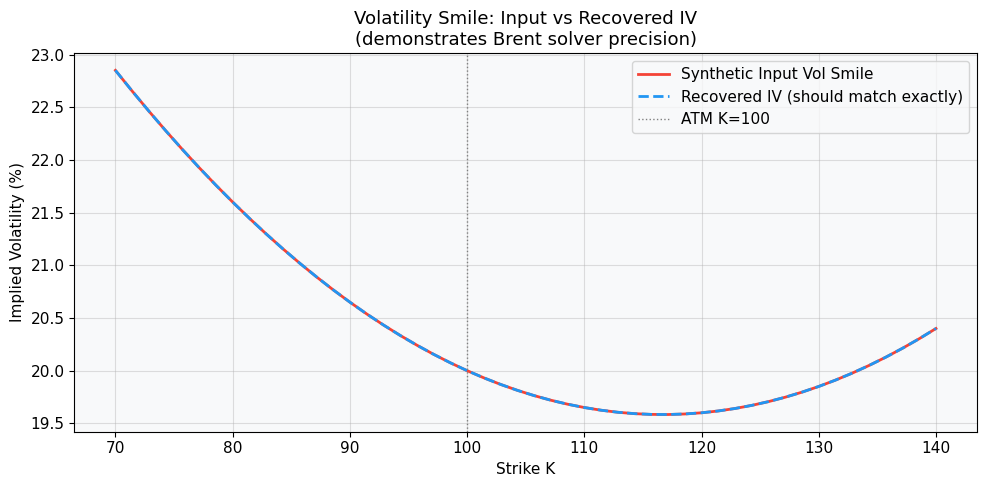

In [8]:
# Round-trip: price → IV → price
test_vols = [0.10, 0.20, 0.30, 0.40, 0.50]
roundtrip_results = []
for vol in test_vols:
    price = bs_call_price(mp.S0, mp.K, mp.r, vol, mp.T)
    iv    = implied_volatility(price, mp.S0, mp.K, mp.r, mp.T, 'call')
    roundtrip_results.append({'Input σ': f'{vol:.0%}', 'BS Price': round(price, 4),
                               'Implied Vol': f'{iv:.8%}', 'Error': f'{abs(iv-vol):.2e}'})

rt_df = pd.DataFrame(roundtrip_results)
print("  Implied Volatility Round-Trip Test")
print(rt_df.to_string(index=False))

# Synthetic IV smile across strikes (as if there were market skew)
# We construct it by injecting a quadratic smile to simulate market data
K_range = np.linspace(70, 140, 50)
skew_vol = 0.20 + 0.15 * ((K_range - 100) / 100) ** 2 - 0.05 * ((K_range - 100) / 100)
market_prices = np.array([bs_call_price(100, k, 0.03, v, 1.0)
                           for k, v in zip(K_range, skew_vol)])
recovered_iv = np.array([implied_volatility(p, 100, k, 0.03, 1.0, 'call')
                          for p, k in zip(market_prices, K_range)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, skew_vol * 100, color='#F44336', lw=2, label='Synthetic Input Vol Smile')
ax.plot(K_range, recovered_iv * 100, color='#2196F3', lw=2, ls='--', label='Recovered IV (should match exactly)')
ax.axvline(100, color='grey', lw=1, ls=':', label='ATM K=100')
ax.set_xlabel('Strike K')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('Volatility Smile: Input vs Recovered IV\n(demonstrates Brent solver precision)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary Table

A comprehensive summary of prices and Greeks across ATM, ITM, and OTM cases.

In [9]:
scenarios = [
    ('Deep OTM Call',  80,  100, 0.03, 0.20, 1.0, 'call'),
    ('OTM Call',       95,  100, 0.03, 0.20, 1.0, 'call'),
    ('ATM Call',      100,  100, 0.03, 0.20, 1.0, 'call'),
    ('ITM Call',      110,  100, 0.03, 0.20, 1.0, 'call'),
    ('Deep ITM Call', 130,  100, 0.03, 0.20, 1.0, 'call'),
    ('ATM Put',       100,  100, 0.03, 0.20, 1.0, 'put'),
    ('ITM Put',        90,  100, 0.03, 0.20, 1.0, 'put'),
]

rows = []
for label, S, K_, r_, sig_, T_, ot in scenarios:
    price = bs_price(S, K_, r_, sig_, T_, ot)
    g_ = bs_all_greeks(S, K_, r_, sig_, T_, ot)
    rows.append({
        'Scenario':   label,
        'S₀':         S,
        'Price ($)':  round(price, 4),
        'Delta':      round(g_['delta'], 4),
        'Gamma':      round(g_['gamma'], 4),
        'Theta/day':  round(g_['theta'], 4),
        'Vega/1%':    round(g_['vega'],  4),
    })

summary_df = pd.DataFrame(rows).set_index('Scenario')
print("\n  Black-Scholes Pricing & Greeks Summary")
print(summary_df.to_string())
print("\n  Key Observations:")
print("  • Deep OTM call has tiny price, Delta≈0, very high Gamma relative to price")
print("  • ATM call has maximum Gamma and Vega (most sensitive to σ moves)")
print("  • Deep ITM call Delta≈1 (behaves like stock); Gamma near zero")
print("  • Put-Call parity: ATM Call - ATM Put = S0 - K·e^{-rT} ≈ 100 - 97.04 ≈ 2.96")


  Black-Scholes Pricing & Greeks Summary
                S₀  Price ($)   Delta   Gamma  Theta/day  Vega/1%
Scenario                                                         
Deep OTM Call   80     1.5617  0.1933  0.0171    -0.0072   0.2194
OTM Call        95     6.6696  0.4974  0.0210    -0.0137   0.3790
ATM Call       100     9.4134  0.5987  0.0193    -0.0147   0.3867
ITM Call       110    16.2837  0.7662  0.0139    -0.0148   0.3370
Deep ITM Call  130    33.6707  0.9408  0.0045    -0.0115   0.1532
ATM Put        100     6.4580 -0.4013  0.0193    -0.0068   0.3867
ITM Put         90    11.4925 -0.6090  0.0213    -0.0040   0.3456

  Key Observations:
  • Deep OTM call has tiny price, Delta≈0, very high Gamma relative to price
  • ATM call has maximum Gamma and Vega (most sensitive to σ moves)
  • Deep ITM call Delta≈1 (behaves like stock); Gamma near zero
  • Put-Call parity: ATM Call - ATM Put = S0 - K·e^{-rT} ≈ 100 - 97.04 ≈ 2.96
